# Bagian A: Operasi pada Sinyal 1D

## A.1 Membuat Sinyal Diskrit
Pembangkitan dua jenis sinyal diskrit dasar dalam rentang indeks sampel $n = 0, 1, 2, \dots, 30$:
1. Sinyal Sinusoidal: $x_1[n] = \sin(0.5\pi n)$
2. Sinyal Unit Step Bergeser: $x_2[n] = 1$ untuk $n \geq 5$, dan $0$ untuk $n < 5$

## A.2 Operasi Penjumlahan Sinyal
Melakukan penjumlahan linier elemen demi elemen (*point-by-point*) antara kedua sinyal:
$$y[n] = x_1[n] + x_2[n]$$

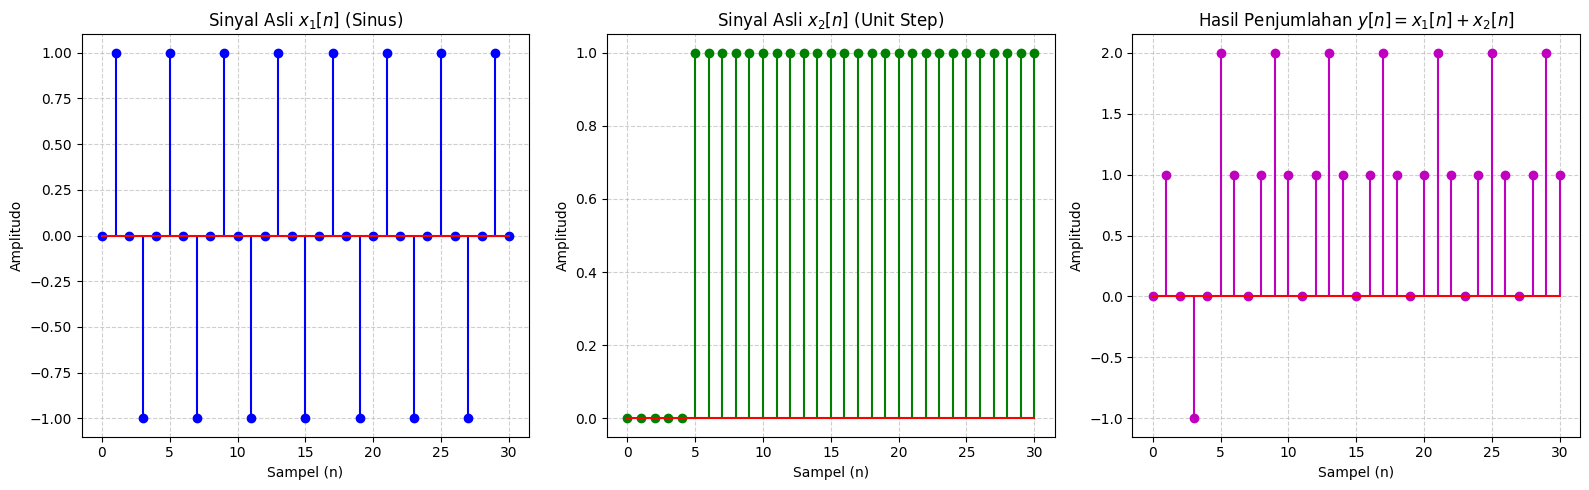

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definisi rentang sampel n (0 sampai 30)
n = np.arange(0, 31)

# 2. Pembangkitan Sinyal Dasar
x1 = np.sin(0.5 * np.pi * n)   # Sinyal Sinus
x2 = np.where(n < 5, 0, 1)     # Sinyal Unit Step

# 3. Operasi Penjumlahan Sinyal
y_add = x1 + x2

# 4. Plot Visualisasi Grafik (Menggunakan stem plot untuk sinyal diskrit)
plt.figure(figsize=(16, 5))

# Plot x1[n]
plt.subplot(1, 3, 1)
plt.stem(n, x1, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title('Sinyal Asli $x_1[n]$ (Sinus)')
plt.xlabel('Sampel (n)')
plt.ylabel('Amplitudo')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot x2[n]
plt.subplot(1, 3, 2)
plt.stem(n, x2, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title('Sinyal Asli $x_2[n]$ (Unit Step)')
plt.xlabel('Sampel (n)')
plt.ylabel('Amplitudo')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot y[n]
plt.subplot(1, 3, 3)
plt.stem(n, y_add, linefmt='m-', markerfmt='mo', basefmt='r-')
plt.title('Hasil Penjumlahan $y[n] = x_1[n] + x_2[n]$')
plt.xlabel('Sampel (n)')
plt.ylabel('Amplitudo')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Analisis Perubahan Bentuk Sinyal setelah Dijumlahkan
Berdasarkan visualisasi di atas, terjadi fenomena *DC offset* atau pergeseran level tegangan searah secara vertikal pada sinyal hasil penjumlahan $y[n]$.
* Pada indeks sampel $0 \leq n < 5$, nilai amplitudo $y[n]$ identik dengan sinyal asli $x_1[n]$ karena komponen pengalinya ($x_2[n]$) bernilai $0$.
* Memasuki indeks sampel $n \geq 5$, seluruh titik sampel sinyal sinus $x_1[n]$ bergeser naik ke atas sebesar $+1$ satuan. Hal ini mengubah batas wilayah ayunan (*range*) amplitudo yang semula berada pada rentang $[-1, 1]$ menjadi naik ke rentang $[0, 2]$.

### Jawaban Pertanyaan Analisis A.2:
1. **Apa yang terjadi pada amplitudo sinyal setelah dilakukan penjumlahan?**
   Amplitudo total mengalami penambahan nilai secara aljabar linier pada setiap sampel ($n$). Jika nilai kedua sinyal pada sampel yang sama memiliki polaritas yang sama, amplitudo akan saling memperkuat (*konstruktif*). Jika polaritasnya berlawanan, amplitudo akan saling memperlemah (*destruktif*), seperti yang terlihat pada sampel $n=3$ di mana nilainya tetap $-1$, namun pada sampel $n=7$ yang harusnya $-1$ berubah menjadi $0$ karena ditambahkan $+1$.

2. **Apakah bentuk sinyal hasil penjumlahan masih menyerupai salah satu sinyal asal?**
   Ya, sinyal hasil penjumlahan masih mempertahankan bentuk osilasi karakteristik periodik dari sinyal sinusoidal asli ($x_1[n]$). Sinyal $x_2[n]$ (unit step) hanya bertindak sebagai penggeser baseline (level acuan nol) gelombang ke atas tanpa merusak frekuensi sudut digital dari komponen sinusnya.

3. **Dalam kasus nyata, operasi penjumlahan sinyal dapat digunakan untuk apa?**
   * **Audio Mixing:** Menggabungkan multi-track rekaman suara instrumen (drum, gitar, bass, vokal) yang terpisah menjadi satu kesatuan file audio tunggal (.mp3/.wav).
   * **Active Noise Cancellation (ANC):** Menjumlahkan sinyal bising dari luar lingkungan dengan sinyal *anti-noise* yang fasenya dibalik $180^\circ$ agar saling menghilangkan (amplitudo akhir mendekati nol).

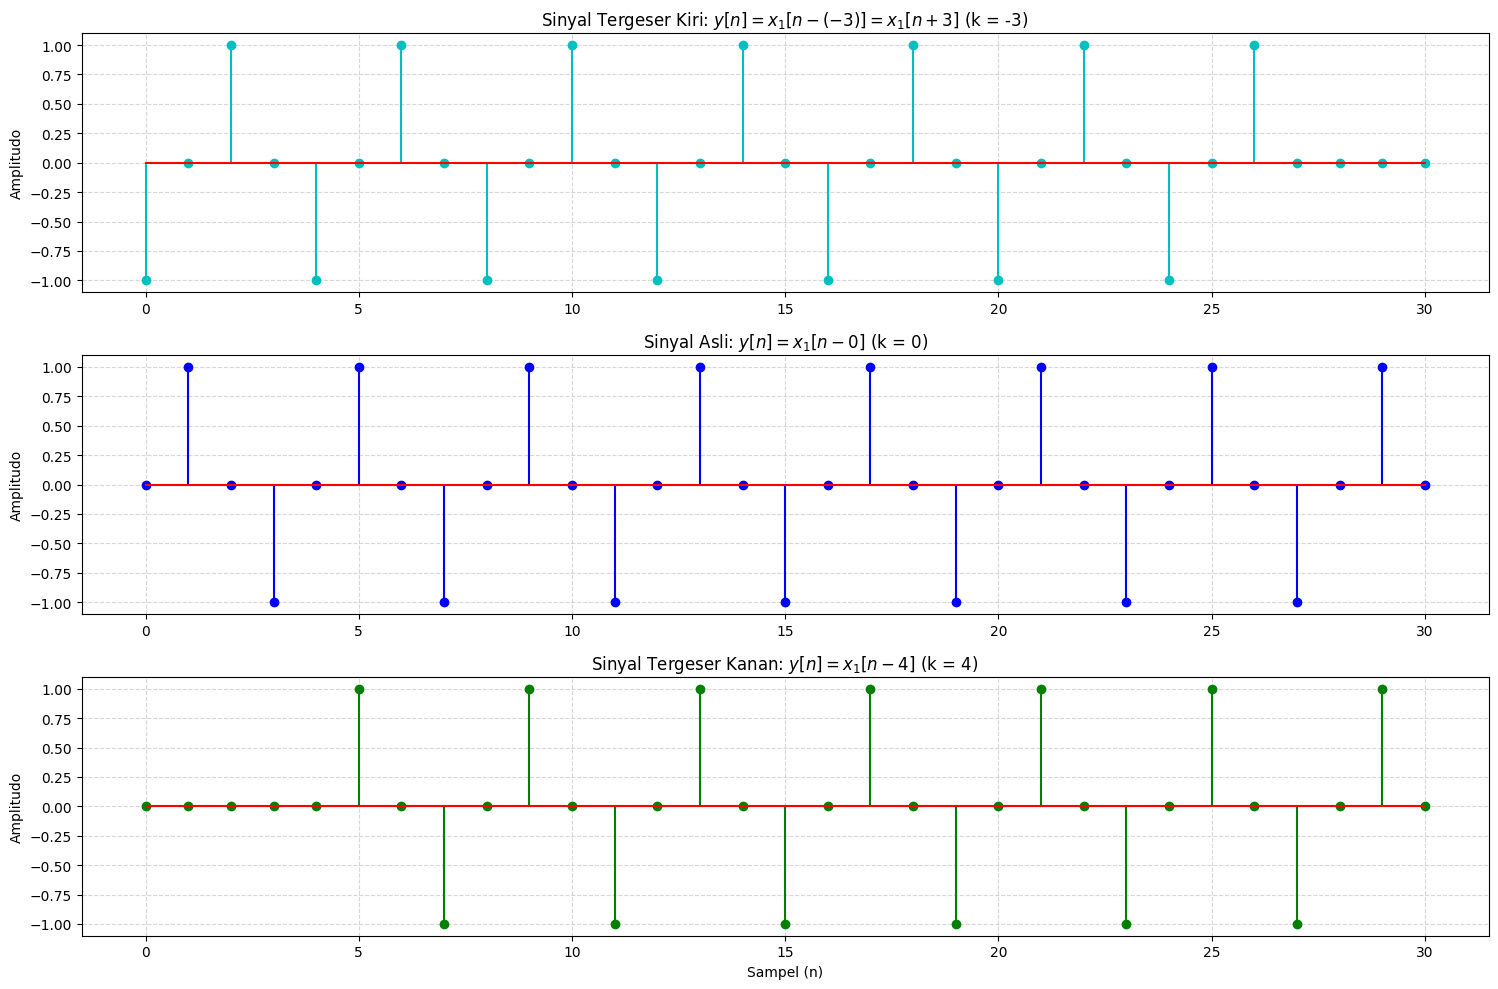

In [ ]:
# A.3 OPERASI PENGGESERAN SINYAL
def geser_sinyal(sinyal, k):

    tergeser = np.roll(sinyal, k)

    if k > 0:
        tergeser[:k] = 0
    elif k < 0:
        tergeser[k:] = 0
    return tergeser

# Melakukan pergeseran pada sinyal sinus x1
y_shift_neg3 = geser_sinyal(x1, -3) # k = -3
y_shift_0    = geser_sinyal(x1, 0)  # k = 0 (asli)
y_shift_pos4 = geser_sinyal(x1, 4)  # k = 4

# Plot perbandingan hasil penggeseran dalam satu gambar
plt.figure(figsize=(15, 10))

# Plot k = -3
plt.subplot(3, 1, 1)
plt.stem(n, y_shift_neg3, linefmt='c-', markerfmt='co', basefmt='r-')
plt.title('Sinyal Tergeser Kiri: $y[n] = x_1[n - (-3)] = x_1[n + 3]$ (k = -3)')
plt.ylabel('Amplitudo')
plt.grid(True, linestyle='--', alpha=0.5)

# Plot k = 0
plt.subplot(3, 1, 2)
plt.stem(n, y_shift_0, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title('Sinyal Asli: $y[n] = x_1[n - 0]$ (k = 0)')
plt.ylabel('Amplitudo')
plt.grid(True, linestyle='--', alpha=0.5)

# Plot k = 4
plt.subplot(3, 1, 3)
plt.stem(n, y_shift_pos4, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title('Sinyal Tergeser Kanan: $y[n] = x_1[n - 4]$ (k = 4)')
plt.xlabel('Sampel (n)')
plt.ylabel('Amplitudo')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Jawaban Pertanyaan Analisis A.3 (Penggeseran Sinyal):
1. **Apa perbedaan efek k positif dan k negatif?**
   * Nilai **$k$ positif ($k = 4$)** pada persamaan $x[n-4]$ menyebabkan sinyal bergeser ke arah **kanan** sepanjang sumbu horizontal. Fenomena ini disebut *Time-Delay* (penundaan waktu).
   * Nilai **$k$ negatif ($k = -3$)** pada persamaan $x[n-(-3)] = x[n+3]$ menyebabkan sinyal bergeser ke arah **kiri**. Fenomena ini disebut *Time-Advance* (percepatan waktu).

2. **Bagaimana penggeseran sinyal dapat digunakan untuk simulasi delay?**
   Simulasi delay fisis dalam kode dilakukan dengan memilih nilai $k > 0$. Hubungan antara waktu tunda nyata (dalam satuan detik, $\Delta t$) dengan jumlah pergeseran indeks sampel diskrit ($k$) ditentukan oleh frekuensi sampling ($f_s$) sistem melalui rumus:
   $$k = \Delta t \times f_s$$
   Array sinyal kemudian digeser ke kanan sebanyak $k$ sampel, dan indeks kosong di bagian awal diisi dengan nilai nol untuk merepresentasikan kondisi hening sebelum sinyal tiba.

3. **Mengapa time alignment penting dalam pengolahan sinyal?**
   * **Sinkronisasi Data:** Mencegah terjadinya tumpang tindih data (*Inter-Symbol Interference*) pada sistem komunikasi digital.
   * **Sensor Fusion:** Menyelaraskan waktu kedatangan data dari berbagai sensor yang letaknya berbeda (misalnya antara kamera, Lidar, dan Radar pada sistem mobil otonom) agar objek yang dideteksi berada pada posisi spasial yang akurat di waktu yang sama.

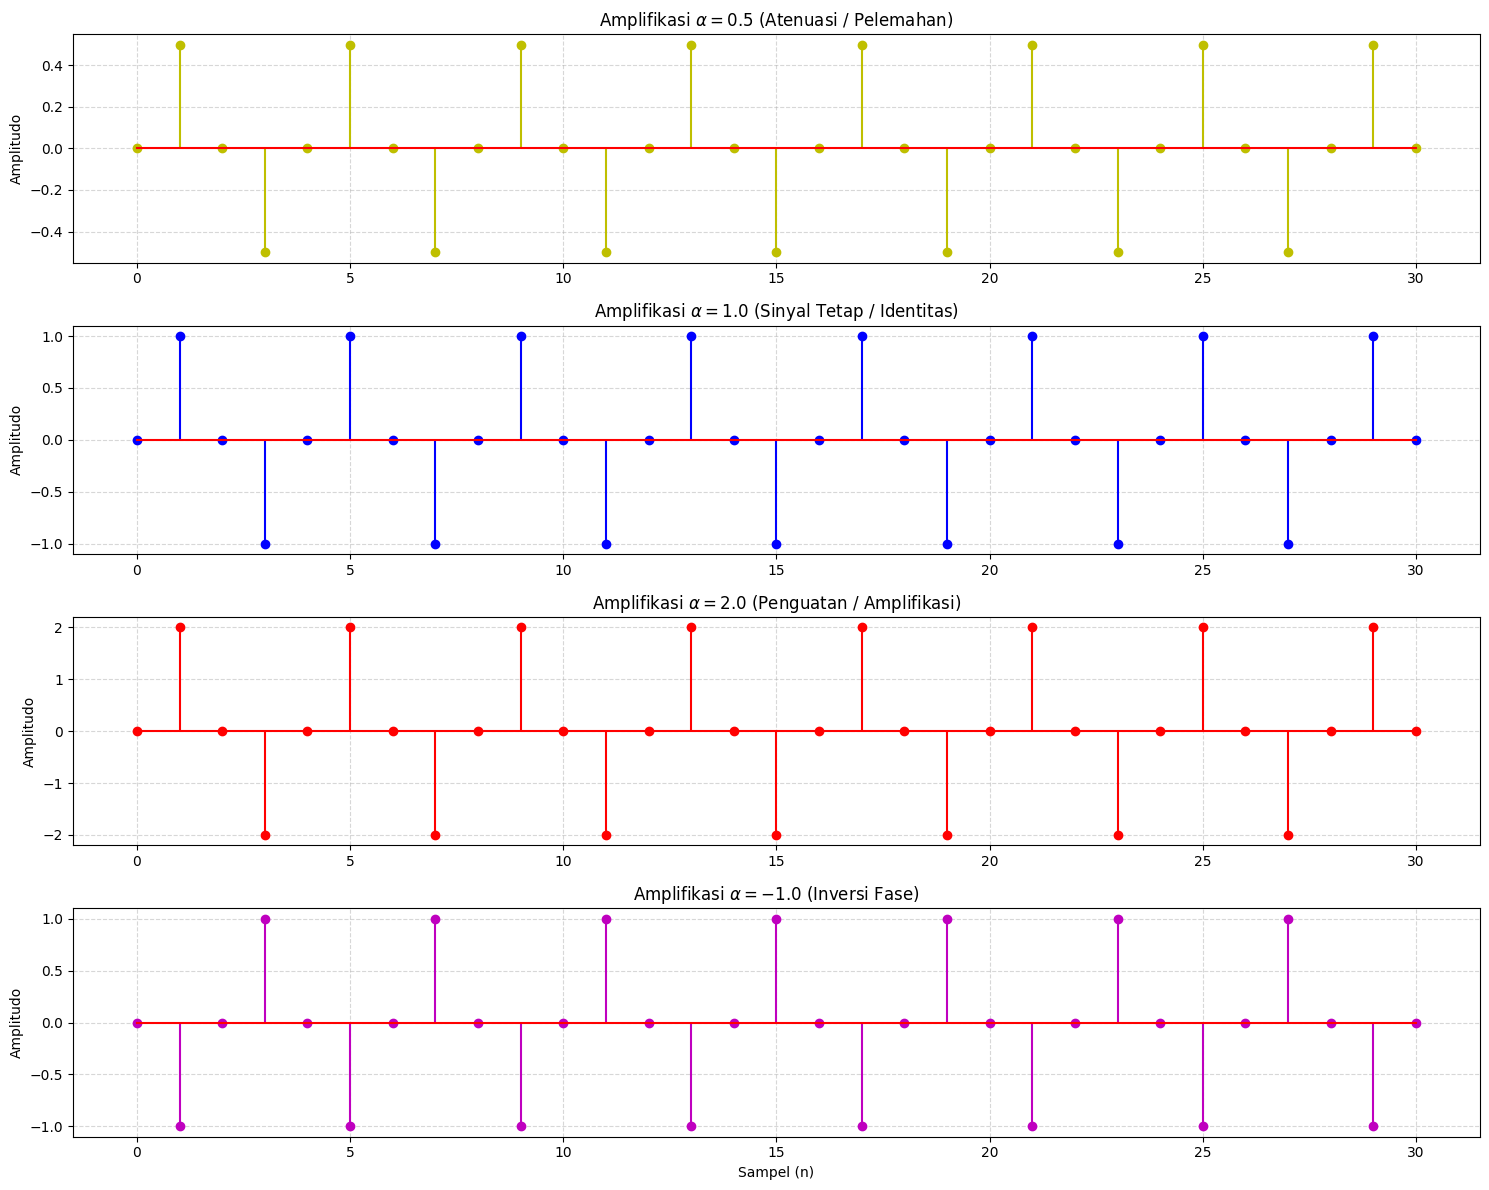

In [ ]:
# A.4 OPERASI AMPLIFIKASI SINYAL (FIXED INITIALIZATION)
import numpy as np
import matplotlib.pyplot as plt

#deklarsi
n = np.arange(0, 31)
x1 = np.sin(0.5 * np.pi * n)

alpha_values = [0.5, 1, 2, -1]
titles = [
    'Amplifikasi $\\alpha = 0.5$ (Atenuasi / Pelemahan)',
    'Amplifikasi $\\alpha = 1.0$ (Sinyal Tetap / Identitas)',
    'Amplifikasi $\\alpha = 2.0$ (Penguatan / Amplifikasi)',
    'Amplifikasi $\\alpha = -1.0$ (Inversi Fase)'
]
colors = ['y', 'b', 'r', 'm']

plt.figure(figsize=(15, 12))

for i, alpha in enumerate(alpha_values):
    # Operasi perkalian
    y_amp = alpha * x1

    plt.subplot(4, 1, i+1)
    plt.stem(n, y_amp, linefmt=f'{colors[i]}-', markerfmt=f'{colors[i]}o', basefmt='r-')
    plt.title(titles[i])
    plt.ylabel('Amplitudo')
    plt.grid(True, linestyle='--', alpha=0.5)
    if i == 3:
        plt.xlabel('Sampel (n)')

plt.tight_layout()
plt.show()

### Tabel Perbandingan Efek Nilai $\alpha$ terhadap Sinyal

| Nilai $\alpha$ | Efek terhadap Sinyal | Deskripsi Teknis |
| :--- | :--- | :--- |
| **0.5** | Pelemahan (*Attenuation*) | Nilai maksimum dan minimum amplitudo menyusut menjadi setengah dari ukuran asli (rentang berubah menjadi $[-0.5, 0.5]$). Grafik merapat ke sumbu horizontal nol. |
| **1** | Tetap (*Identity*) | Tidak terjadi perubahan karena nilai sinyal dikalikan dengan elemen identitas. Rentang amplitudo tetap $[-1, 1]$. |
| **2** | Penguatan (*Amplification*) | Amplitudo sinyal meningkat dua kali lipat (rentang berubah menjadi $[-2, 2]$), mempertinggi daya puncak gelombang tanpa mengubah frekuensi. |
| **-1** | Inversi Fase (*Phase Inversion*) | Magnitudo puncak tetap 1, namun polaritasnya berbalik $180^\circ$. Sampel yang awalnya bernilai positif berubah menjadi negatif, dan sebaliknya. |

### Jawaban Pertanyaan Analisis A.4:
1. **Apa yang terjadi ketika $\alpha > 1$?**
   Sinyal mengalami penguatan (*amplification*). Secara visual, bentuk gelombang meregang menjauhi sumbu horizontal (garis nol), menunjukkan adanya peningkatan daya atau tegangan sinyal.

2. **Apa yang terjadi ketika $0 < \alpha < 1$?**
   Sinyal mengalami pelemahan (*atenuasi* atau *compression*). Bentuk gelombang menyusut secara vertikal dan merapat ke arah sumbu nol, yang merepresentasikan penurunan energi sinyal.

3. **Apa yang terjadi ketika $\alpha$ bernilai negatif?**
   Terjadi pembalikan fase (*inversion*) sebesar $180^\circ$. Puncak gelombang (*peak*) berubah menjadi lembah (*trough*), dan lembah berubah menjadi puncak. Jika nilai $|\alpha| > 1$, inversi fase terjadi bersamaan dengan penguatan amplitudo.

4. **Bagaimana konsep amplifikasi ini berkaitan dengan gain pada sistem audio?**
   Operasi perkalian skalar $\alpha$ adalah representasi matematis dari pengaturan *Gain* atau tombol *Volume* pada perangkat audio digital. Ketika kita menaikkan volume, sistem sebenarnya sedang mengalikan setiap sampel data audio (array sinyal) dengan nilai skalar $\alpha > 1$ agar suara yang dihasilkan speaker terdengar lebih keras. Sebaliknya, menurunkan volume berarti mengalikan dengan skalar $0 < \alpha < 1$.
   

# Bagian B: Operasi pada Citra 2D

## B.1 Membaca dan Menampilkan Citra & B.2 Operasi Penjumlahan Citra
Pada bagian ini, citra asli dimuat menggunakan OpenCV dalam format grayscale. Untuk memenuhi syarat operasi penjumlahan matriks dua citra ($I = I_1 + I_2$), ukuran dimensi kedua gambar harus identik. Citra kedua dibuat dengan memodifikasi citra pertama secara matematis agar dimensinya sama persis tanpa perlu proses resizing eksternal. Eksperimen ini juga menguji penanganan luapan nilai piksel (*clipping*) karena nilai maksimum piksel bertipe `uint8` adalah 255.

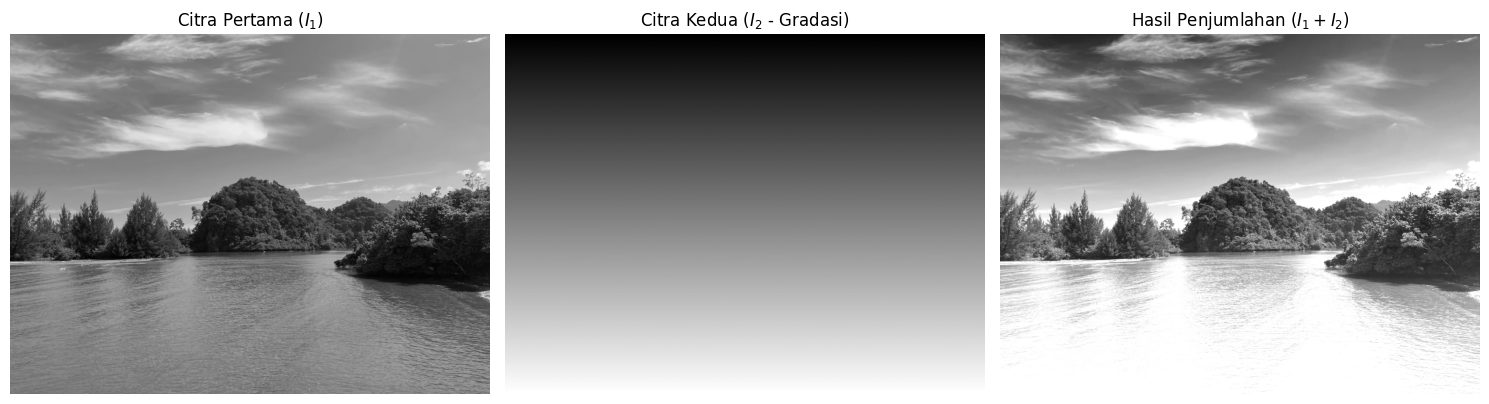

Ukuran Citra Asli (Height x Width) : 1199 x 1599 piksel
Tipe Data Array Citra              : uint8
Nilai Piksel Minimum Citra Asli    : 0
Nilai Piksel Maksimum Citra Asli   : 255


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Membaca Citra Pertama (Grayscale)
img_path = '/content/sample_data/1.jpeg'  # <-- SESUAIKAN DENGAN NAMA FILE FOTOMU DI COLAB
img1 = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img1 is None:
    print("Error: File gambar tidak ditemukan! uplod foto")
else:

    h, w = img1.shape
    img2 = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        img2[i, :] = int((i / h) * 150)


    img_hasil_penjumlahan = cv2.add(img1, img2)


    tipe_data = img1.dtype
    piksel_min = np.min(img1)
    piksel_max = np.max(img1)


    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img1, cmap='gray')
    plt.title('Citra Pertama ($I_1$)')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(img2, cmap='gray')
    plt.title('Citra Kedua ($I_2$ - Gradasi)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(img_hasil_penjumlahan, cmap='gray')
    plt.title('Hasil Penjumlahan ($I_1 + I_2$)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # 6. Menampilkan teks metadata citra
    print("=" * 50)
    print(f"Ukuran Citra Asli (Height x Width) : {h} x {w} piksel")
    print(f"Tipe Data Array Citra              : {tipe_data}")
    print(f"Nilai Piksel Minimum Citra Asli    : {piksel_min}")
    print(f"Nilai Piksel Maksimum Citra Asli   : {piksel_max}")
    print("=" * 50)

## B.3 Operasi Penggeseran Citra (Translasi)
Operasi pergeseran spasial pada citra digital (translasi) dihitung berdasarkan pemetaan koordinat baru $I'(i, j) = I(i - \Delta i, j - \Delta j)$. Parameter $\Delta i$ merepresentasikan nilai pergeseran secara vertikal (ke bawah/atas), sedangkan $\Delta j$ merepresentasikan pergeseran horizontal (ke kanan/kiri). Eksperimen dilakukan menggunakan tiga variasi kombinasi:
1. $\Delta i = 30, \Delta j = 0$ (Geser ke bawah sebesar 30 piksel)
2. $\Delta i = 0, \Delta j = 30$ (Geser ke kanan sebesar 30 piksel)
3. $\Delta i = 30, \Delta j = 30$ (Geser diagonal ke kanan-bawah sebesar 30 piksel)

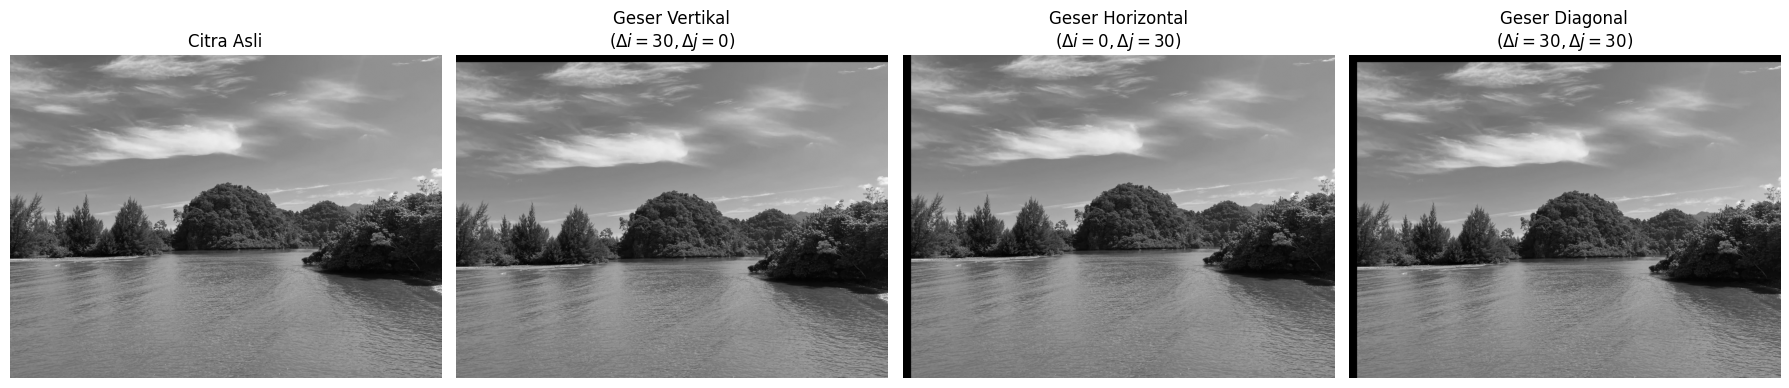

In [10]:
# B.3 OPERASI PENGGESERAN CITRA (TRANSLASI)
h, w = img1.shape
# Kombinasi 1: Delta_i = 30, Delta_j = 0
M1 = np.float32([[1, 0, 0], [0, 1, 30]])
img_shift1 = cv2.warpAffine(img1, M1, (w, h))
# Kombinasi 2: Delta_i = 0, Delta_j = 30
M2 = np.float32([[1, 0, 30], [0, 1, 0]])
img_shift2 = cv2.warpAffine(img1, M2, (w, h))
# Kombinasi 3: Delta_i = 30, Delta_j = 30
M3 = np.float32([[1, 0, 30], [0, 1, 30]])
img_shift3 = cv2.warpAffine(img1, M3, (w, h))
# Visualisasi perbandingan hasil translasi citra
plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.imshow(img1, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_shift1, cmap='gray')
plt.title('Geser Vertikal\n($\\Delta i=30, \\Delta j=0$)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_shift2, cmap='gray')
plt.title('Geser Horizontal\n($\\Delta i=0, \\Delta j=30$)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_shift3, cmap='gray')
plt.title('Geser Diagonal\n($\\Delta i=30, \\Delta j=30$)')
plt.axis('off')

plt.tight_layout()
plt.show()

### Analisis Efek Translasi dan Jawaban Pertanyaan B.3:
* **Penjelasan Area Kosong setelah Penggeseran:** Saat matriks gambar digeser, baris atau kolom piksel pada tepi asal akan ditinggalkan oleh konten gambar asli. Karena tidak ada data piksel baru yang mengisi kekosongan koordinat spasial tersebut, fungsi `cv2.warpAffine` secara otomatis memberikan nilai default berupa $0$ (berwarna hitam pekat) pada area tepian yang kosong tersebut.

1. **Apa efek penggeseran terhadap posisi objek dalam citra?**
   Posisi objek mengalami perpindahan lokasi koordinat piksel secara linier tanpa mengubah bentuk geometri, skala, maupun orientasi rotasi objek gambar. Objek bergeser secara spasial mengikuti arah parameter $\Delta i$ dan $\Delta j$.

2. **Mengapa translasi digunakan dalam augmentasi data?**
   Dalam pelatihan model *Machine Learning* atau *Deep Learning* (seperti CNN), operasi translasi acak digunakan sebagai teknik *data augmentation*. Tujuannya agar model AI memiliki sifat *Translation Invariance*—yaitu kemampuan mendeteksi objek dengan akurat di mana pun posisi spasial objek tersebut berada di dalam frame (tidak harus selalu persis di tengah gambar).

3. **Apa risiko penggunaan penggeseran yang terlalu besar pada citra?**
   Jika nilai pergeseran terlalu ekstrem, informasi penting atau objek utama (*Region of Interest*) yang ingin diamati pada citra bisa terpotong keluar dari batas dimensi kanvas gambar ($H \times W$). Selain itu, porsi area kosong hitam pekat di tepian akan mendominasi gambar sehingga merusak distribusi data piksel asli citra.

## B.4 Operasi Amplifikasi Citra
Operasi amplifikasi citra dilakukan dengan cara mengalikan setiap nilai elemen matriks piksel dengan sebuah nilai skalar penguat berdasarkan fungsi $I'(i, j) = \alpha \cdot I(i, j)$. Parameter $\alpha$ berfungsi untuk mengatur tingkat kecerahan (*brightness*) sekaligus kontras pada citra. Eksperimen ini menggunakan variasi nilai $\alpha = 0.5, 1, 1.5,$ dan $2$. Untuk menganalisis distribusi sebaran intensitas piksel secara detail, visualisasi histogram citra disertakan untuk setiap perubahan parameter $\alpha$.


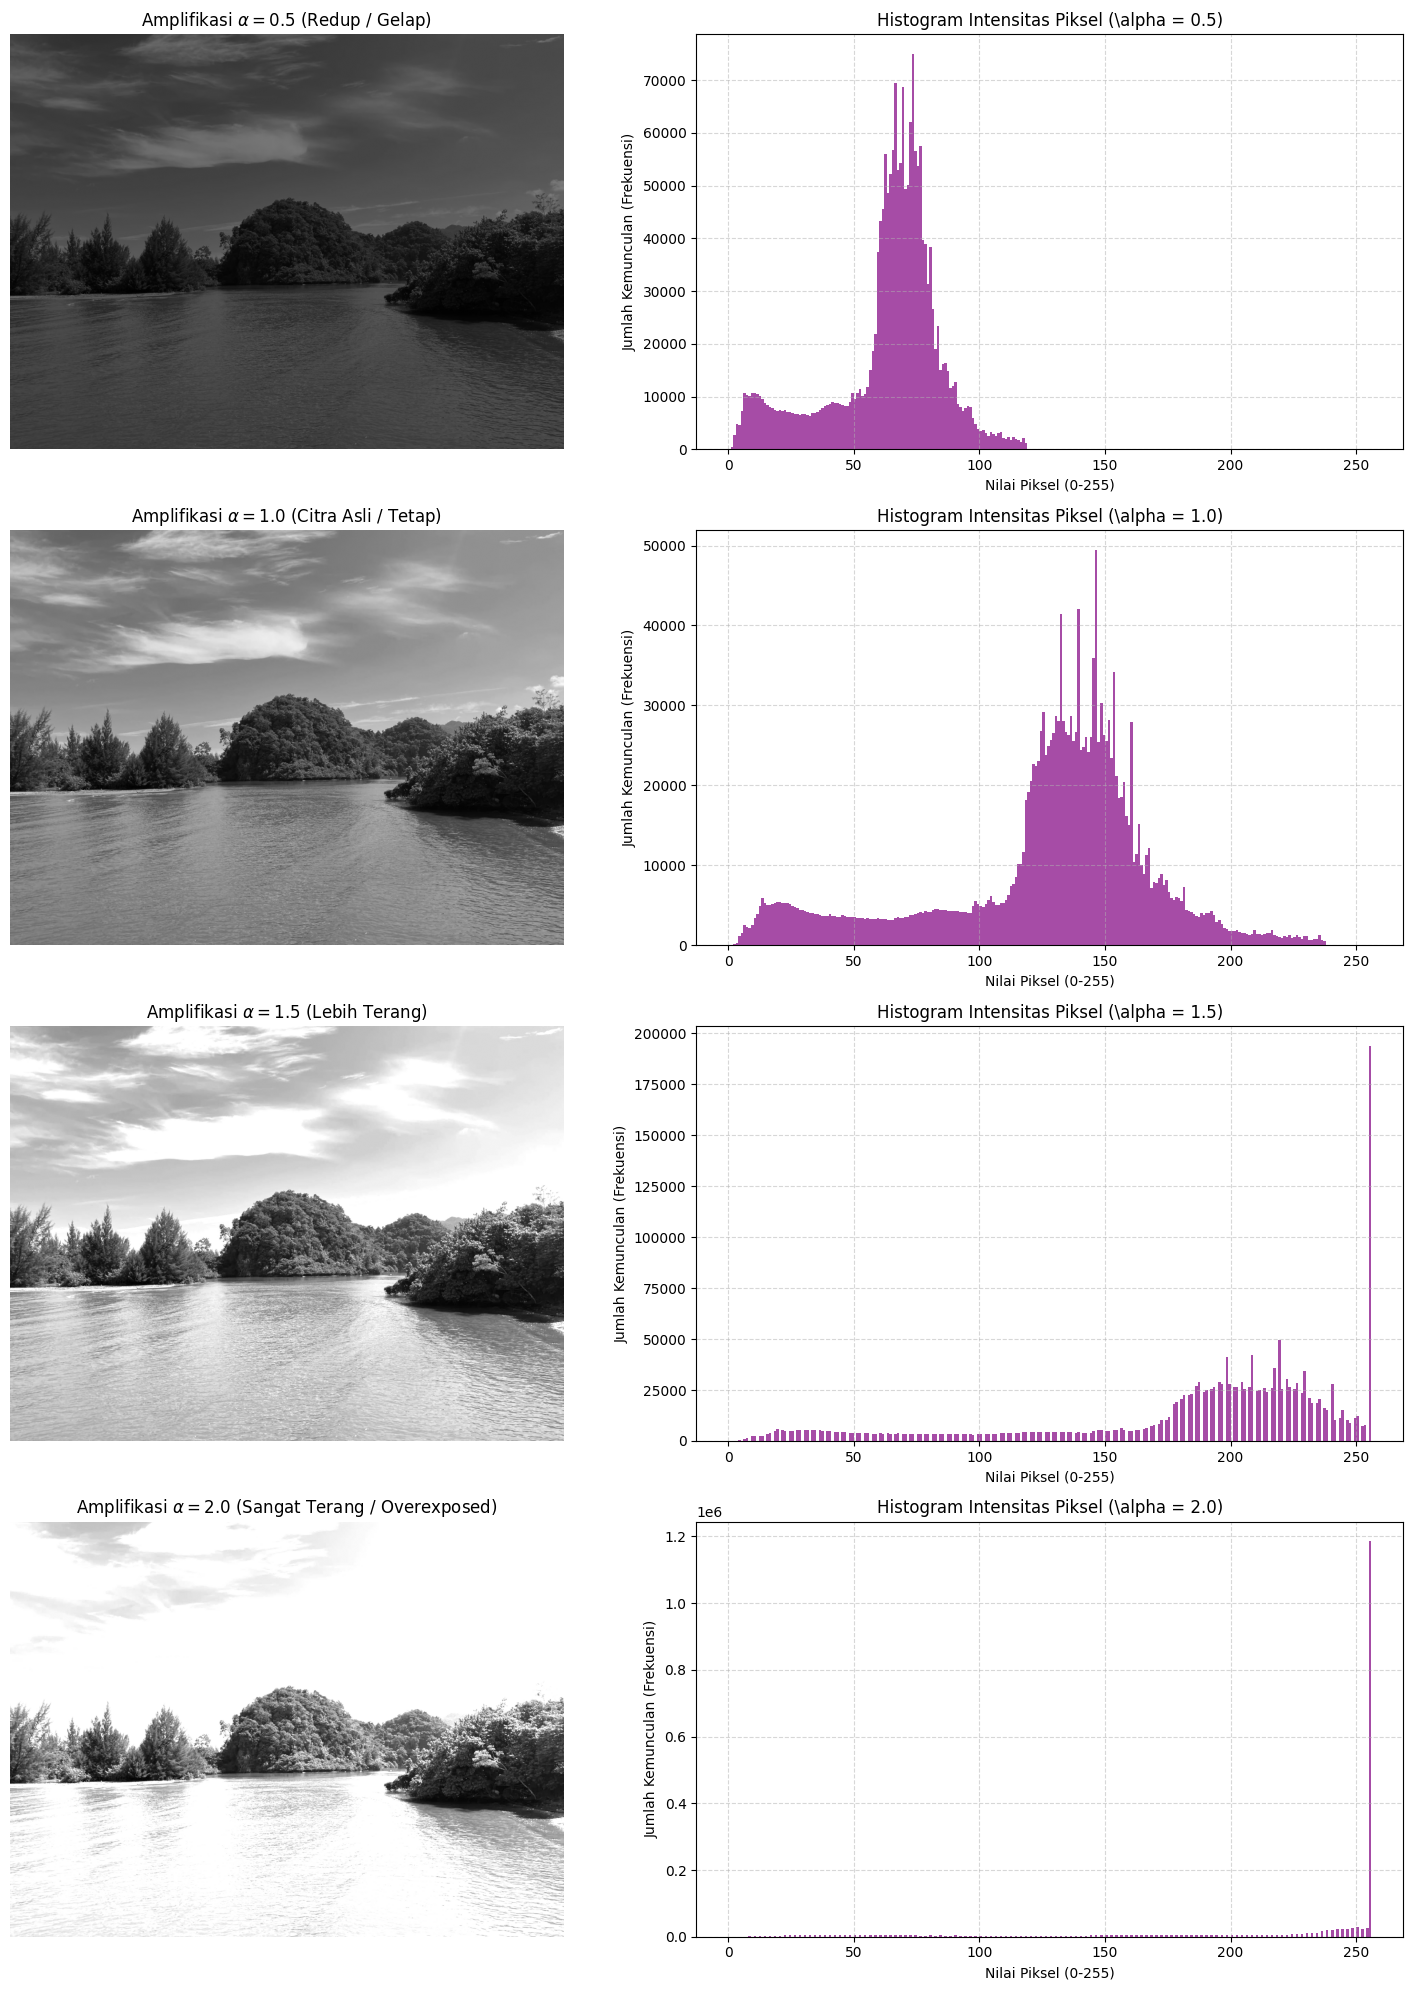

In [11]:
# B.4 OPERASI AMPLIFIKASI CITRA DAN HISTOGRAM
# Menggunakan variabel img1 (foto asli 1.jpeg)

alpha_vals = [0.5, 1.0, 1.5, 2.0]
titles_amp = [
    'Amplifikasi $\\alpha = 0.5$ (Redup / Gelap)',
    'Amplifikasi $\\alpha = 1.0$ (Citra Asli / Tetap)',
    'Amplifikasi $\\alpha = 1.5$ (Lebih Terang)',
    'Amplifikasi $\\alpha = 2.0$ (Sangat Terang / Overexposed)'
]
fig, axs = plt.subplots(4, 2, figsize=(15, 20))

for i, alpha in enumerate(alpha_vals):
    img_amp = np.clip(alpha * img1, 0, 255).astype(np.uint8)
    # 1. Plot Gambar di Kolom Kiri (Kolom 0)
    axs[i, 0].imshow(img_amp, cmap='gray', vmin=0, vmax=255)
    axs[i, 0].set_title(titles_amp[i], fontsize=12)
    axs[i, 0].axis('off')
    # 2. Plot Histogram di Kolom Kanan (Kolom 1)
    # Meratakan matriks 2D menjadi 1D dengan .ravel() untuk menghitung distribusi frekuensi piksel
    axs[i, 1].hist(img_amp.ravel(), bins=256, range=(0, 256), color='purple', alpha=0.7)
    axs[i, 1].set_title(f'Histogram Intensitas Piksel (\\alpha = {alpha})', fontsize=12)
    axs[i, 1].set_xlabel('Nilai Piksel (0-255)')
    axs[i, 1].set_ylabel('Jumlah Kemunculan (Frekuensi)')
    axs[i, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### Analisis Perubahan Brightness & Kontras dan Jawaban Pertanyaan B.4:
* **Analisis Grafik Histogram:** Perubahan nilai $\alpha$ berdampak signifikan pada bentuk visual grafik distribusi histogram. Ketika $\alpha = 0.5$, grafik histogram bergeser merapat ke sisi kiri mendekati nilai $0$ (dominan gelap). Sebaliknya, saat nilai $\alpha$ dinaikkan menjadi $1.5$ dan $2.0$, grafik sebaran piksel meregang melebar ke arah kanan mendekati nilai $255$. Pada $\alpha = 2.0$, terlihat lonjakan garis vertikal sangat tinggi tepat di angka $255$ yang menandakan penumpukan nilai akibat *clipping*.

1. **Apa efek $\alpha > 1$ pada citra?**
   Citra akan menjadi jauh lebih cerah (*brightness enhancement*) karena nilai intensitas setiap piksel bertambah besar. Jarak antar nilai piksel juga melebar sehingga kontras gambar meningkat. Namun, jika terlalu besar, detail pada area terang akan hilang dan memutih (*overexposure*).

2. **Apa efek $0 < \alpha < 1$ pada citra?**
   Citra akan terlihat semakin redup, gelap, dan kusam. Jarak rentang sebaran nilai piksel menyempit ke arah nilai rendah (kiri), yang mengakibatkan hilangnya kontras dan detail di area bayangan (*underexposure*).

3. **Mengapa nilai pixel perlu dibatasi pada rentang tertentu?**
   Karena representasi citra digital 8-bit (`uint8`) secara fisis di memori komputer dibatasi hanya mampu menampung rentang nilai dari $0$ (hitam sempurna) hingga $255$ (putih sempurna). Jika operasi matematika menghasilkan nilai melebihi $255$ tanpa dibatasi (`np.clip`), komputer akan mengalami error *modulo overflow* yang membuat nilai piksel kembali berputar dari nol (misalnya nilai $256$ dibaca menjadi $0$ hitam, yang mengakibatkan distorsi warna aneh merusak gambar).

4. **Apa hubungan amplifikasi citra dengan peningkatan brightness?**
   Amplifikasi citra melalui perkalian skalar merupakan salah satu cara paling fundamental untuk memanipulasi tingkat kecerahan (*brightness*). Skalar $\alpha$ bertindak sebagai penguat linier yang langsung meningkatkan magnitudo nilai piksel gambar secara keseluruhan, membuat area yang awalnya abu-abu sedang berubah menjadi putih terang.

# Bagian C: Uji Sistem Linier

Sistem linier adalah sistem yang memenuhi prinsip superposisi, yang terdiri dari dua sifat mutlak: Homogenitas dan Additivitas. Bagian ini akan menguji dan membuktikan karakteristik linearitas pada dua buah sistem pemrosesan matematika, yaitu sistem linier $T_1(x) = 2x$ dan sistem non-linier $T_2(x) = x^2$.

## C.1 Uji Homogenitas & C.2 Uji Additivitas pada Sistem $T_1(x) = 2x$
Pengujian dilakukan menggunakan sinyal input dasar $x_1[n]$ dan $x_2[n]$ yang telah dibuat pada Bagian A dengan parameter skalar $\alpha = 3$.

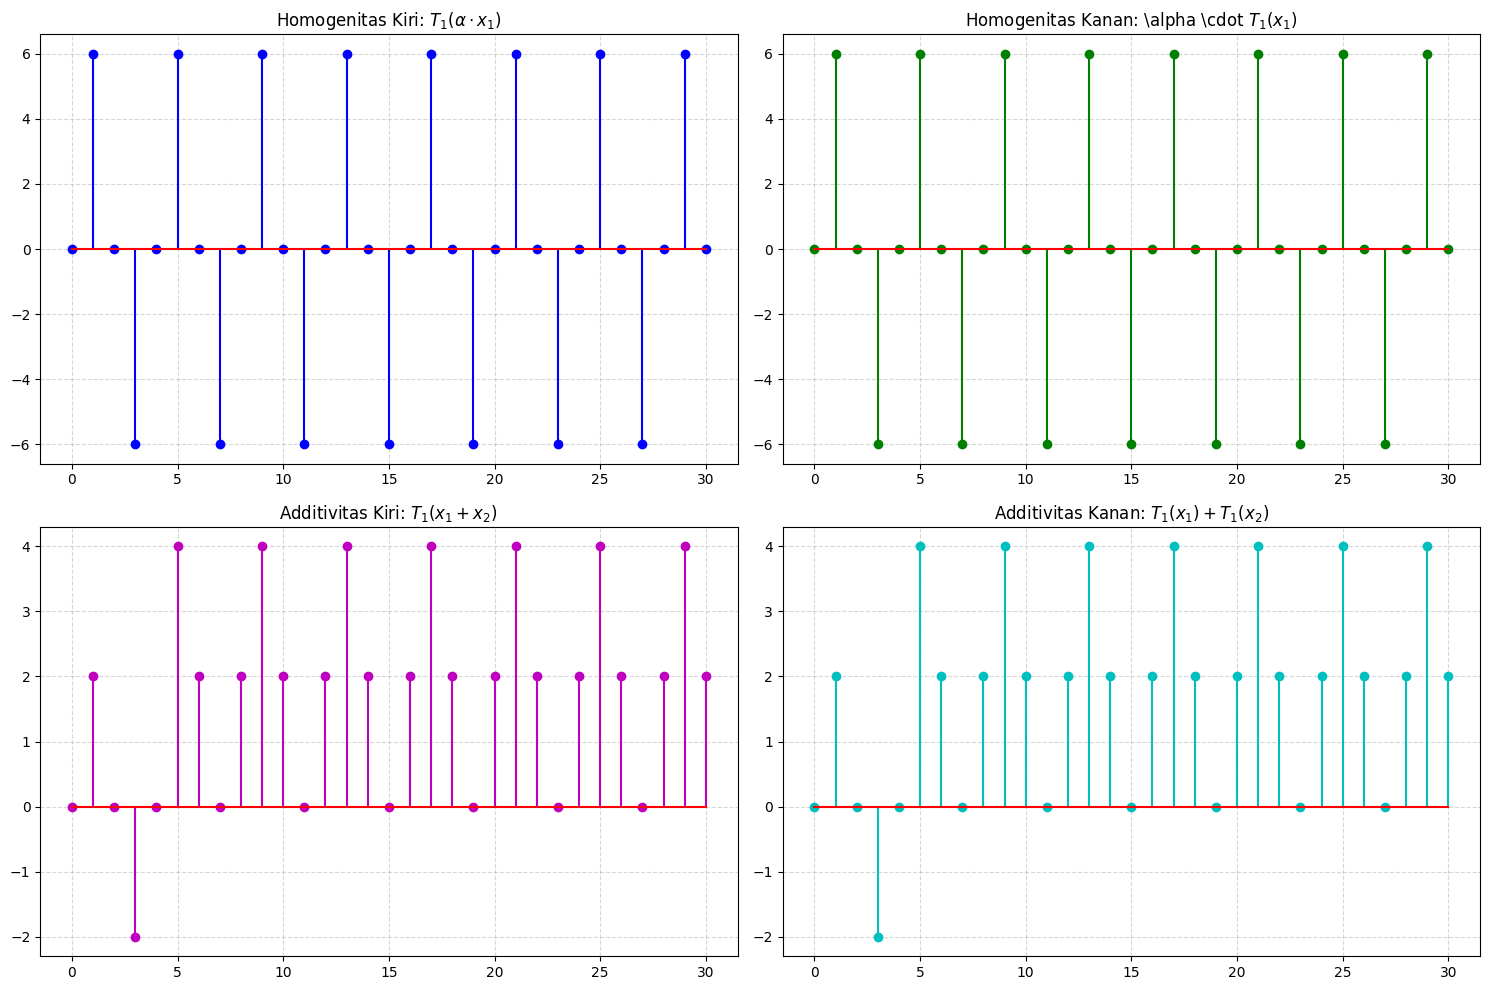

Total Selisih Uji Homogenitas Sistem T1 : 0.0
Total Selisih Uji Additivitas Sistem T1 : 0.0
Kesimpulan Sementara: Karena selisih = 0, Sistem T1 MEMENUHI Homogenitas & Additivitas.


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Pastikan sinyal dasar x1 dan x2 dari Bagian A terdefinisi
n = np.arange(0, 31)
x1 = np.sin(0.5 * np.pi * n)
x2 = np.where(n < 5, 0, 1)
alpha = 3.0

# 2. Definisi Sistem T1(x) = 2x
def T1(x):
    return 2 * x
    # --- UJI HOMOGENITAS T1 ---
# Sisi kiri persamaan: T(alpha * x)
out_homo_kiri = T1(alpha * x1)
# Sisi kanan persamaan: alpha * T(x)
out_homo_kanan = alpha * T1(x1)
selisih_homo = out_homo_kiri - out_homo_kanan

# --- UJI ADDITIVITAS T1 ---
out_add_kiri = T1(x1 + x2)
# Sisi kanan persamaan: T(x1) + T(x2)
out_add_kanan = T1(x1) + T1(x2)
selisih_add = out_add_kiri - out_add_kanan
# 3. Visualisasi Hasil Uji Sistem T1
plt.figure(figsize=(15, 10))
# Plot Uji Homogenitas T1
plt.subplot(2, 2, 1)
plt.stem(n, out_homo_kiri, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title('Homogenitas Kiri: $T_1(\\alpha \\cdot x_1)$')
plt.grid(True, linestyle='--', alpha=0.5)
plt.subplot(2, 2, 2)
plt.stem(n, out_homo_kanan, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title('Homogenitas Kanan: \\alpha \\cdot $T_1(x_1)$')
plt.grid(True, linestyle='--', alpha=0.5)
# Plot Uji Additivitas T1
plt.subplot(2, 2, 3)
plt.stem(n, out_add_kiri, linefmt='m-', markerfmt='mo', basefmt='r-')
plt.title('Additivitas Kiri: $T_1(x_1 + x_2)$')
plt.grid(True, linestyle='--', alpha=0.5)
plt.subplot(2, 2, 4)
plt.stem(n, out_add_kanan, linefmt='c-', markerfmt='co', basefmt='r-')
plt.title('Additivitas Kanan: $T_1(x_1) + T_1(x_2)$')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("=" * 60)
print(f"Total Selisih Uji Homogenitas Sistem T1 : {np.sum(np.abs(selisih_homo))}")
print(f"Total Selisih Uji Additivitas Sistem T1 : {np.sum(np.abs(selisih_add))}")
print("Kesimpulan Sementara: Karena selisih = 0, Sistem T1 MEMENUHI Homogenitas & Additivitas.")
print("=" * 60)

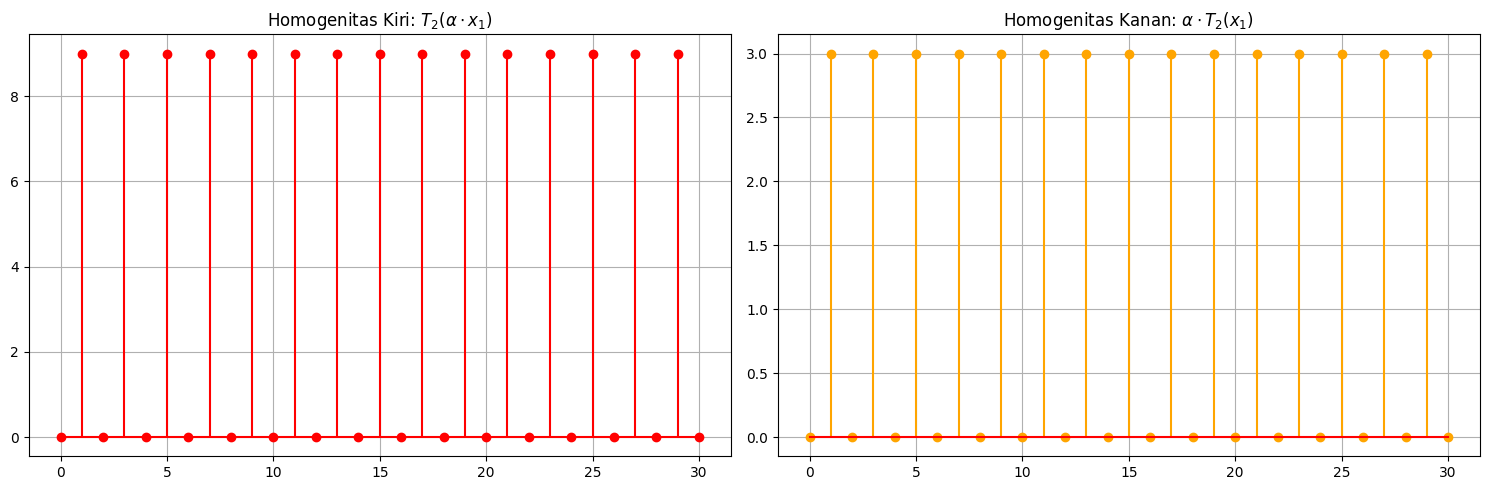

Total Selisih Uji Homogenitas Sistem T2 : 90.0
Total Selisih Uji Additivitas Sistem T2 : 26.000000000000043
Kesimpulan Sementara: Karena selisih TIDAK NOL, Sistem T2 GAGAL memenuhi sifat linier.


In [18]:
# 1. Definisi Sistem T2(x) = x^2
def T2(x):
    return x ** 2

# --- UJI HOMOGENITAS T2 ---
out_homo_kiri_2 = T2(alpha * x1)
out_homo_kanan_2 = alpha * T2(x1)
selisih_homo_2 = out_homo_kiri_2 - out_homo_kanan_2

# --- UJI ADDITIVITAS T2 ---
out_add_kiri_2 = T2(x1 + x2)
out_add_kanan_2 = T2(x1) + T2(x2)
selisih_add_2 = out_add_kiri_2 - out_add_kanan_2

# 2. Visualisasi Perbandingan Sisi Kiri vs Sisi Kanan pada T2 (Fixed Marker Formatting)
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.stem(n, out_homo_kiri_2, linefmt='r-', markerfmt='ro', basefmt='r-')
plt.title('Homogenitas Kiri: $T_2(\\alpha \\cdot x_1)$')
plt.grid(True)lt.subplot(1, 2, 2)
plt.stem(n, out_homo_kanan_2, linefmt='orange', markerfmt='o', basefmt='r-'plt.title('Homogenitas Kanan: $\\alpha \\cdot T_2(x_1)$')
plt.grid(True)
plt.tight_layout()
plt.show()
print("=" * 60)
print(f"Total Selisih Uji Homogenitas Sistem T2 : {np.sum(np.abs(selisih_homo_2))}")
print(f"Total Selisih Uji Additivitas Sistem T2 : {np.sum(np.abs(selisih_add_2))}")
print("Kesimpulan Sementara: Karena selisih TIDAK NOL, Sistem T2 GAGAL memenuhi sifat linier.")
print("=" * 60)

# Bagian D: Analisis HOTS

## D.1 Analisis Konseptual
1. **Mengapa operasi penjumlahan dan amplifikasi menjadi dasar dari konsep superposisi?**
   Prinsip superposisi menyatakan bahwa respon total sistem terhadap kombinasi input linier sama dengan jumlah respon individualnya masing-masing. Penjumlahan merepresentasikan penggabungan sinyal secara simultan (sifat additivitas), sedangkan amplifikasi merepresentasikan penskalaan magnitudo sinyal secara proporsional (sifat homogenitas). Tanpa kedua operasi dasar ini, pembuktian kombinasi linier $T(\alpha x_1 + \beta x_2) = \alpha T(x_1) + \beta T(x_2)$ tidak dapat didefinisikan.

2. **Mengapa tidak semua operasi pada sinyal dapat dianggap linier?**
   Karena banyak operasi fisis atau matematis yang menghasilkan perubahan non-proporsional terhadap inputnya. Operasi seperti pengkuadratan ($x^2$), nilai mutlak ($|x|$), logaritma, operasi pembatasan ambang (*thresholding*), serta pemotongan piksel (*clipping*) menciptakan komponen frekuensi harmonis baru (distorsi) atau melanggar hukum distribusi aljabar, sehingga tidak lolos uji homogenitas atau additivitas.

3. **Apa dampaknya jika suatu sistem tidak linier terhadap hasil pemrosesan sinyal?**
   Sistem non-linier akan memicu terjadinya distorsi bentuk gelombang. Pada sinyal audio, ini menghasilkan suara sember/pecah (*clipping distortion*). Pada pemrosesan sinyal komunikasi, non-linearitas menyebabkan interferensi antar-saluran. Secara matematis, sistem non-linier juga sangat sulit diprediksi karena kita tidak bisa lagi menggunakan tools analisis standar seperti fungsi transfer, konvolusi, maupun transformasi Fourier langsung pada sinyalnya.

4. **Mengapa operasi sederhana seperti shift dan amplify penting dalam aplikasi nyata?**
   Meskipun terlihat sederhana, kedua operasi ini merupakan elemen pembangun inti (*building blocks*) sistem pengolahan sinyal yang kompleks. Operasi *shift* (penggeseran) adalah fondasi dari kalkulasi konvolusi, filtering digital, efek *reverb/echo*, serta pengetahuian estimasi jarak pada Radar. Sementara itu, operasi *amplify* (perkalian skalar) merupakan komponen mutlak pengatur sensitivitas sensor (*calibration*), pengaturan volume audio (*gain control*), serta pengkondisian sinyal lemah sebelum masuk ke unit ADC.

---

## D.2 Analisis Aplikasi Nyata (Studi Kasus: Data Augmentation pada Citra)
1. **Masalah yang Ingin Diselesaikan:** Keterbatasan jumlah sampel dataset pada pelatihan model kecerdasan buatan (*Deep Learning* seperti CNN) yang sering memicu terjadinya *overfitting* (model hanya pintar menghafal data latihan tapi gagal mendeteksi gambar baru di dunia nyata).
2. **Operasi Sinyal/Citra yang Digunakan:** Operasi penggeseran spasial (Translasi gambar $\Delta i, \Delta j$) dan perkalian skalar (Amplifikasi nilai piksel $\alpha$).
3. **Mengapa Operasi Tersebut Relevan:** Operasi *shift* memaksa model CNN mengenali objek tanpa bergantung pada posisi koordinatnya (*translation invariance*), misalnya mendeteksi objek di pojok atas maupun tengah gambar. Operasi *amplify* menyimulasikan variasi kondisi pencahayaan cuaca (siang terang terang menderang atau malam redup) agar model kebal terhadap perubahan intensitas cahaya sekitar.
4. **Linearitas Sistem:** Sistem augmentasi ini secara keseluruhan bersifat **Non-Linier** jika melibatkan parameter pembatasan nilai piksel (*clipping* di batas 0-255) sewaktu mengubah kecerahan, karena operasi pemotongan nilai melanggar prinsip additivitas matriks.
5. **Kelebihan dan Keterbatasan:** * *Kelebihan:* Sangat mudah diimplementasikan secara komputasi, tidak butuh biaya untuk mengambil foto baru di lapangan, dan terbukti ampuh mendongkrak akurasi generalisasi model AI.
   * *Keterbatasan:* Jika parameter geser atau pengali terlalu ekstrem, objek utama pada foto bisa terpotong keluar kanvas atau mengalami kerusakan detail akibat terlalu putih (*overexposed*) atau terlalu hitam (*underexposed*).

---

## D.3 Skenario Pengambilan Keputusan
* **Skenario 1 (Image Blending Beda Ukuran):** Langkah yang harus dilakukan adalah melakukan **Resizing** (mengubah ukuran resolusi) salah satu atau kedua citra terlebih dahulu menggunakan interpolasi (misal `cv2.resize()`) agar dimensi tinggi dan lebarnya sama persis. Alasannya, *image blending* didasari oleh operasi penjumlahan matriks secara elemen demi elemen (*element-by-element*). Jika dimensinya berbeda, aljabar linear matriks tidak valid dan program akan langsung mengeluarkan error *dimension mismatch*.
* **Skenario 2 (Audio Terlalu Kecil):** Operasi yang harus dilakukan adalah **Amplifikasi Sinyal** dengan mengalikan array audio dengan konstanta $\alpha > 1$ (meningkatkan *Gain*). Risiko jika nilai $\alpha$ terlalu besar adalah terjadinya **Clipping Distortion**. Amplitudo gelombang suara akan melampaui batas maksimum perangkat keras (titik jenuh), memotong puncak-puncak gelombang menjadi datar, dan menghasilkan suara digital yang pecah, bising, dan rusak merusak telinga.
* **Skenario 3 (Deteksi Objek Gagal akibat Variasi Posisi):** Operasi **Penggeseran Citra (Translasi)** dapat digunakan untuk merekayasa data (*data augmentation*). Dengan membuat salinan gambar baru yang digeser secara acak ke kanan, kiri, atas, dan bawah, kita memaksa algoritma detektor objek untuk mempelajari fitur bentuk esensial dari objek itu sendiri, bukan menghafal lokasi koordinat piksel tempat objek tersebut muncul di gambar awal.
* **Skenario 4 (Urutan Filter dan Amplifikasi Ditukar):** Jika hasil outputnya berbeda ketika urutan ditukar, maka sistem tersebut **Kemungkinan Besar Adalah Non-Linier**. Pada sistem linier yang terhubung secara berurutan (*cascade*), berlaku sifat komutatif di mana urutan blok filter ($H$) dan penguat ($\alpha$) bebas ditukar tanpa mengubah respon akhir sistem ($H(\alpha \cdot x) = \alpha \cdot H(x)$). Perbedaan output menandakan salah satu komponen di dalam filter atau penguat tersebut memiliki fungsi non-linier (seperti adanya operasi saturasi atau pembatasan nilai).